In [47]:
# Load libraries
import pandas as pd
from sklearn.tree import DecisionTreeClassifier # Import Decision Tree Classifier
from sklearn.model_selection import train_test_split # Import train_test_split function
from sklearn import metrics #Import scikit-learn metrics module for accuracy calculation
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

In [48]:
#col_names = ['pregnant', 'glucose', 'bp', 'skin', 'insulin', 'bmi', 'pedigree', 'age', 'label']
# load dataset
pima = pd.read_csv(r"diabetes.csv")


In [49]:
print(pima.head())
pima .columns


   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [56]:
pima.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [58]:
pima["Pregnancies"].unique()
pima.shape

(768, 9)

In [50]:
#split dataset in features and target variable
feature_cols =['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age']
X = pima[feature_cols] # Features
y = pima.Outcome # Target variable


In [51]:
# Split dataset into training set and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1) # 70% training and 30% test



In [52]:
# Assuming 'Pregnancies' is a categorical variable
# Perform one-hot encoding on the entire dataset
#le=labelEncoder()
 #= pd.get_dummies(X)

# Split the dataset into training and test sets
#X_train_encoded, X_test_encoded, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, random_state=1)

# Create Decision Tree classifier object
clf = DecisionTreeClassifier(max_depth=3)

# Train Decision Tree classifier
clf.fit(X_train, y_train)

# Predict the response for the test dataset
y_pred = clf.predict(X_test)


In [53]:
# Model Accuracy, how often is the classifier correct?
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))


Accuracy: 0.7575757575757576


In [54]:
#feature_names_encoded = X_encoded.columns.tolist()
pima

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [59]:
from sklearn import tree
text_representation = tree.export_text(clf)
print(text_representation)

|--- feature_1 <= 129.50
|   |--- feature_5 <= 26.30
|   |   |--- feature_5 <= 9.10
|   |   |   |--- class: 0
|   |   |--- feature_5 >  9.10
|   |   |   |--- class: 0
|   |--- feature_5 >  26.30
|   |   |--- feature_7 <= 27.50
|   |   |   |--- class: 0
|   |   |--- feature_7 >  27.50
|   |   |   |--- class: 0
|--- feature_1 >  129.50
|   |--- feature_5 <= 27.85
|   |   |--- feature_1 <= 145.50
|   |   |   |--- class: 0
|   |   |--- feature_1 >  145.50
|   |   |   |--- class: 0
|   |--- feature_5 >  27.85
|   |   |--- feature_1 <= 158.50
|   |   |   |--- class: 1
|   |   |--- feature_1 >  158.50
|   |   |   |--- class: 1



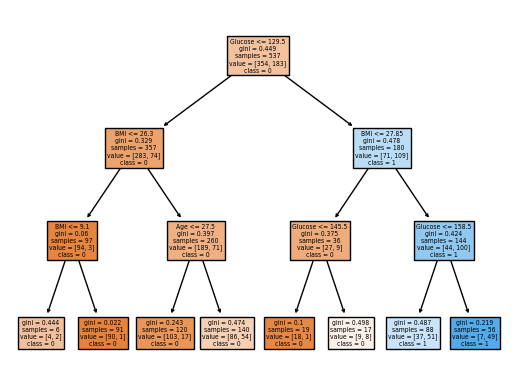

In [62]:
fig = plt.figure()
_ = plot_tree(clf, 
                   feature_names=X.columns,  
                   class_names=["0","1"],
                   filled=True)